In [6]:
# ============================================
# IMPORTS
# ============================================
import os
import time
import pandas as pd
import numpy as np
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import torch

# ============================================
# MODEL INITIALIZATION
# ============================================

class SentimentAnalyzer:
    def __init__(self, your_model_repo="Kaizen696/my_lead_model"):
        print("🔧 Initializing sentiment analyzers...")

        # --- 1. TextBlob (Local / Rule-based) ---
        print("✓ TextBlob ready")

        # --- 2. VADER (Local / Rule-based) ---
        self.vader = SentimentIntensityAnalyzer()
        print("✓ VADER ready")

        # --- 3. DistilBERT SST-2 (Local / Baseline) ---
        print("⏳ Loading DistilBERT (SST-2 baseline)...")
        self.distilbert = pipeline(
            "sentiment-analysis",
            model="distilbert-base-uncased-finetuned-sst-2-english",
            device=-1
        )
        print("✓ DistilBERT ready")

        # --- 4. Twitter-RoBERTa (Local / Slang) ---
        print("⏳ Loading Twitter-RoBERTa...")
        self.twitter_roberta = pipeline(
            "sentiment-analysis",
            model="cardiffnlp/twitter-roberta-base-sentiment-latest",
            device=-1
        )
        print("✓ Twitter-RoBERTa ready")

        # --- 5. Your Fine-Tuned Model (v2 — domain adapted) ---
        print(f"⏳ Loading your model ({your_model_repo})...")
        self.your_model = pipeline(
            "text-classification",
            model=your_model_repo,
            device=-1
        )
        print("✓ Your model ready")

        print("\n🎉 All models initialized!\n")

    # ============================================
    # ANALYZER METHODS
    # ============================================

    def textblob_analyze(self, text):
        polarity = TextBlob(text).sentiment.polarity
        if polarity > 0.1:
            return "POSITIVE", polarity
        elif polarity < -0.1:
            return "NEGATIVE", polarity
        else:
            return "NEUTRAL", polarity

    def vader_analyze(self, text):
        scores = self.vader.polarity_scores(text)
        compound = scores['compound']
        if compound >= 0.05:
            return "POSITIVE", compound
        elif compound <= -0.05:
            return "NEGATIVE", compound
        else:
            return "NEUTRAL", compound

    def distilbert_analyze(self, text):
        result = self.distilbert(text[:512])[0]
        label = result['label']
        score = result['score'] if label == 'POSITIVE' else -result['score']
        return label, score

    def twitter_roberta_analyze(self, text):
        result = self.twitter_roberta(text[:512])[0]
        label_map = {'positive': 'POSITIVE', 'negative': 'NEGATIVE', 'neutral': 'NEUTRAL'}
        label = label_map.get(result['label'].lower(), result['label'].upper())
        score = result['score'] if 'positive' in result['label'].lower() else -result['score']
        return label, score

    def your_model_analyze(self, text):
        result = self.your_model(text[:512])[0]
        # Your model's config labels should be LABEL_0/1/2 or negative/neutral/positive
        # depending on how config.json id2label was saved — adjust mapping if needed
        raw_label = result['label'].upper()
        label_map = {
            'LABEL_0': 'NEGATIVE', 'NEGATIVE': 'NEGATIVE',
            'LABEL_1': 'NEUTRAL', 'NEUTRAL': 'NEUTRAL',
            'LABEL_2': 'POSITIVE', 'POSITIVE': 'POSITIVE'
        }
        label = label_map.get(raw_label, raw_label)
        score = result['score'] if label == 'POSITIVE' else (-result['score'] if label == 'NEGATIVE' else 0.0)
        return label, score

    def analyze_all(self, text):
        results = {}
        results['TextBlob'] = self.textblob_analyze(text)
        results['VADER'] = self.vader_analyze(text)
        results['DistilBERT (SST-2 baseline)'] = self.distilbert_analyze(text)
        results['Twitter-RoBERTa'] = self.twitter_roberta_analyze(text)
        results['Your Model (v2)'] = self.your_model_analyze(text)
        return results

    def compare_on_dataset(self, texts, true_labels=None):
        """Run all models on a list of texts, return a DataFrame for comparison."""
        rows = []
        for i, text in enumerate(texts):
            results = self.analyze_all(text)
            row = {"text": text}
            for model_name, (label, score) in results.items():
                row[f"{model_name}_label"] = label
                row[f"{model_name}_score"] = round(score, 4)
            if true_labels is not None:
                row["true_label"] = true_labels[i]
            rows.append(row)
        return pd.DataFrame(rows)

# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":
    analyzer = SentimentAnalyzer()

    print("="*50)
    print("✅ SETUP COMPLETE!")
    print("="*50)

    test_cases = [
        "Not interested at all. They are happy with their current vendor.",
        "Really impressed, asked for the contract right after the call.",
        "Still weighing a few options, nothing decided yet.",
        "Budget is approved, excited to move forward.",
        "Too expensive, they went with a competitor."
    ]

    print("\n🚀 Comparing models on test cases:\n")
    df = analyzer.compare_on_dataset(test_cases)
    pd.set_option('display.max_colwidth', 40)
    print(df.to_string(index=False))

    # Save for README / report use
    df.to_csv("model_comparison.csv", index=False)
    print("\n💾 Saved comparison to model_comparison.csv")

🔧 Initializing sentiment analyzers...
✓ TextBlob ready
✓ VADER ready
⏳ Loading DistilBERT (SST-2 baseline)...


Device set to use cpu


✓ DistilBERT ready
⏳ Loading Twitter-RoBERTa...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


✓ Twitter-RoBERTa ready
⏳ Loading your model (Kaizen696/my_lead_model)...


Device set to use cpu


✓ Your model ready

🎉 All models initialized!

✅ SETUP COMPLETE!

🚀 Comparing models on test cases:

                                                            text TextBlob_label  TextBlob_score VADER_label  VADER_score DistilBERT (SST-2 baseline)_label  DistilBERT (SST-2 baseline)_score Twitter-RoBERTa_label  Twitter-RoBERTa_score Your Model (v2)_label  Your Model (v2)_score
Not interested at all. They are happy with their current vendor.       POSITIVE          0.2250    POSITIVE       0.3489                          POSITIVE                             0.9995              NEGATIVE                -0.5832              POSITIVE                 0.8365
  Really impressed, asked for the contract right after the call.       POSITIVE          0.6429    POSITIVE       0.5256                          POSITIVE                             0.9994              POSITIVE                 0.9757              POSITIVE                 0.9635
              Still weighing a few options, nothing decided

📊 Test dataset: 48 samples
   - POSITIVE: 15
   - NEGATIVE: 21
   - NEUTRAL: 12

🔄 Running comparison on 48 texts...

[1/48] I love this product!...


  TextBlob                      : POSITIVE (+0.625)
  VADER                         : POSITIVE (+0.670)
  DistilBERT (SST-2 baseline)   : POSITIVE (+1.000)
  Twitter-RoBERTa               : POSITIVE (+0.985)
  Your Model (v2)               : POSITIVE (+0.930)

[2/48] This is amazing and wonderful...
  TextBlob                      : POSITIVE (+0.800)
  VADER                         : POSITIVE (+0.818)
  DistilBERT (SST-2 baseline)   : POSITIVE (+1.000)
  Twitter-RoBERTa               : POSITIVE (+0.981)
  Your Model (v2)               : POSITIVE (+0.914)

[3/48] Best purchase ever!...
  TextBlob                      : POSITIVE (+1.000)
  VADER                         : POSITIVE (+0.670)
  DistilBERT (SST-2 baseline)   : POSITIVE (+1.000)
  Twitter-RoBERTa               : POSITIVE (+0.977)
  Your Model (v2)               : POSITIVE (+0.953)

[4/48] I hate this. Terrible....
  TextBlob                      : NEGATIVE (-0.900)
  VADER                         : NEGATIVE (-0.809)
  DistilBE

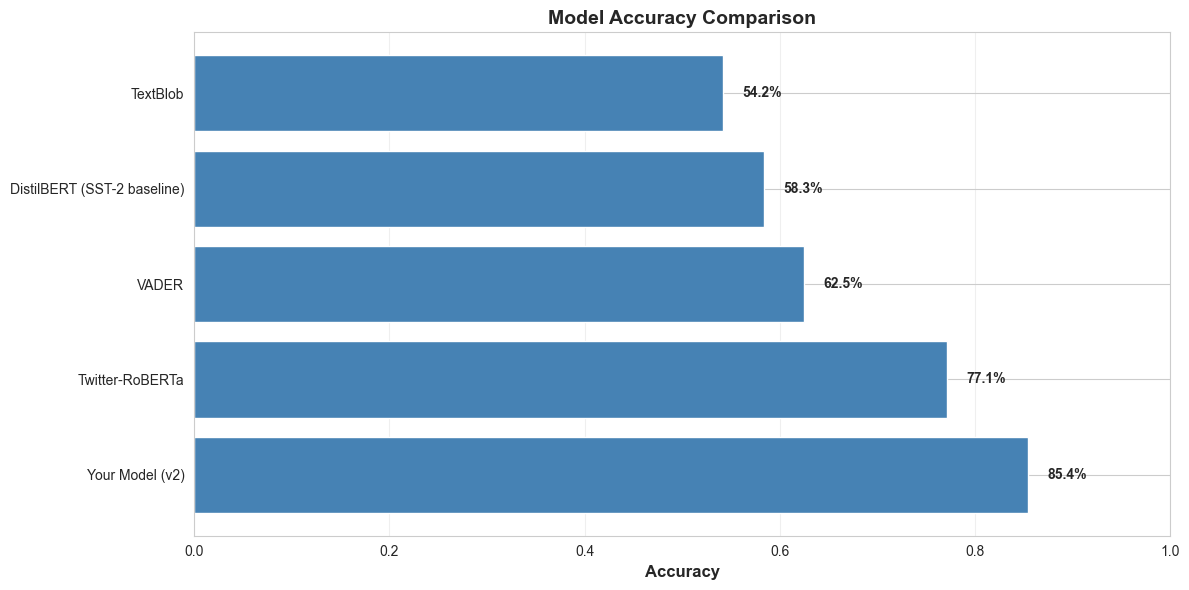

💾 Saved: sentiment_confusion_matrices.png


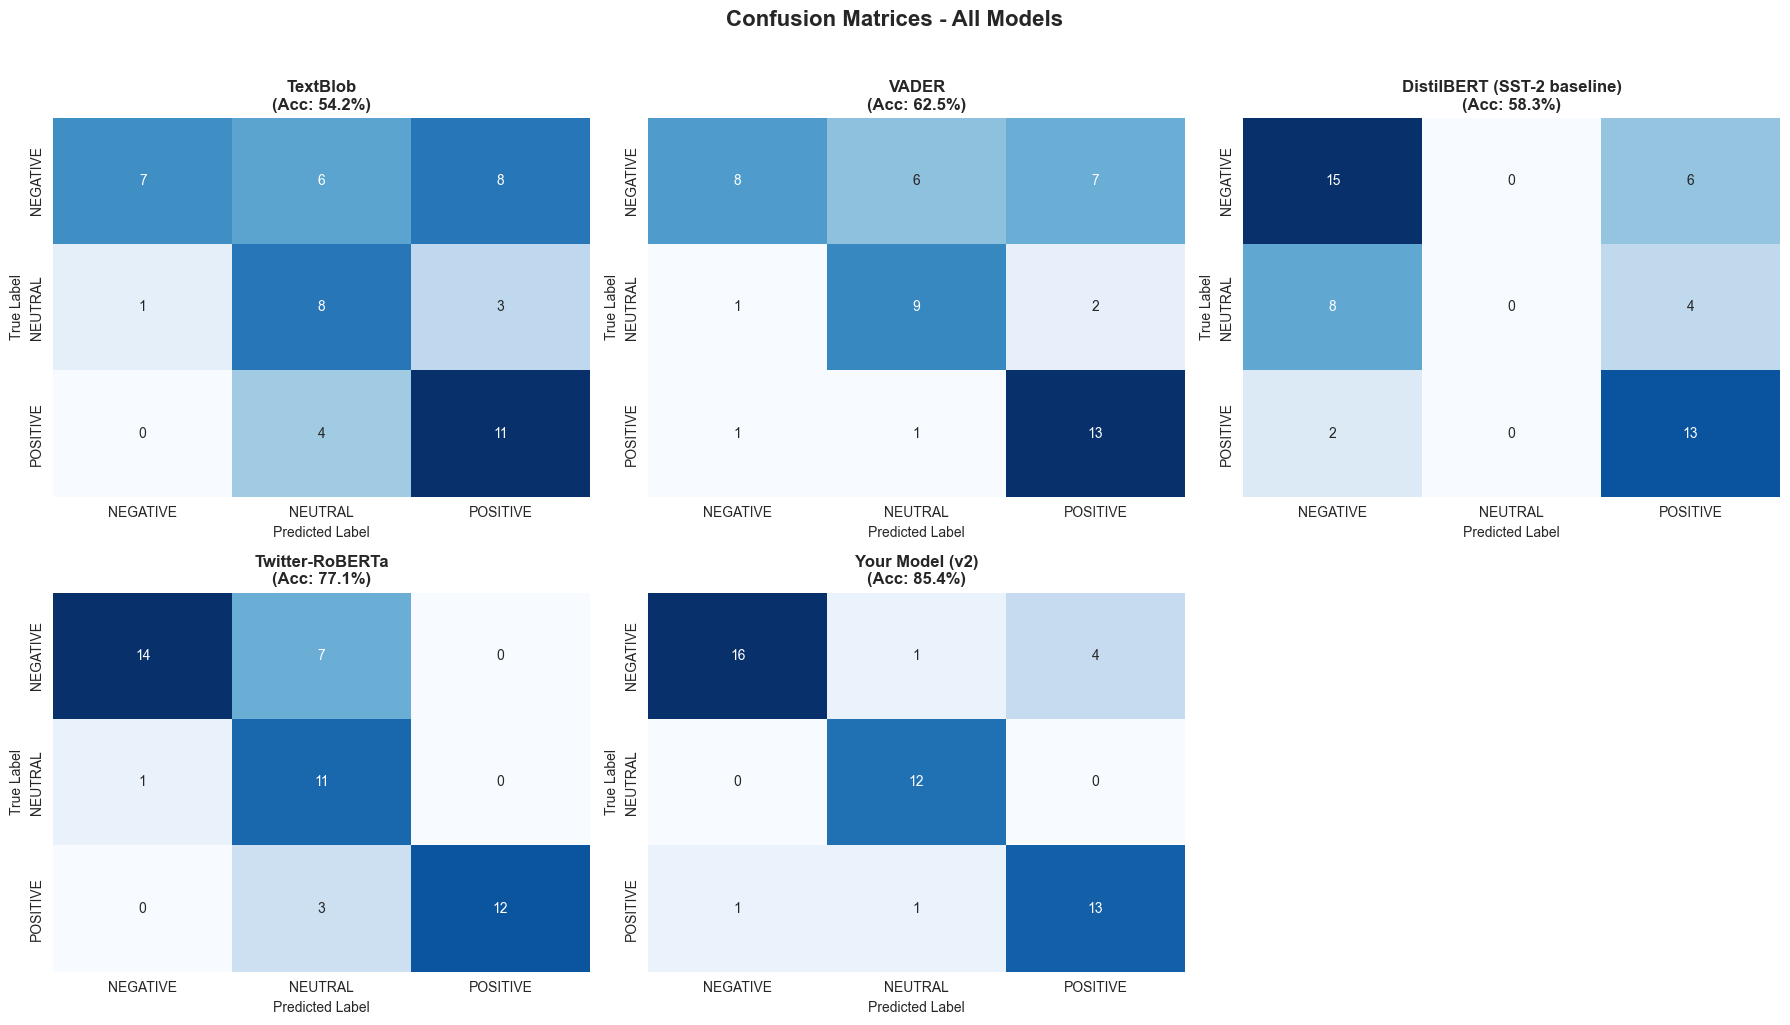

💾 Saved: sentiment_score_distribution.html


💾 Saved: sentiment_model_agreement.png


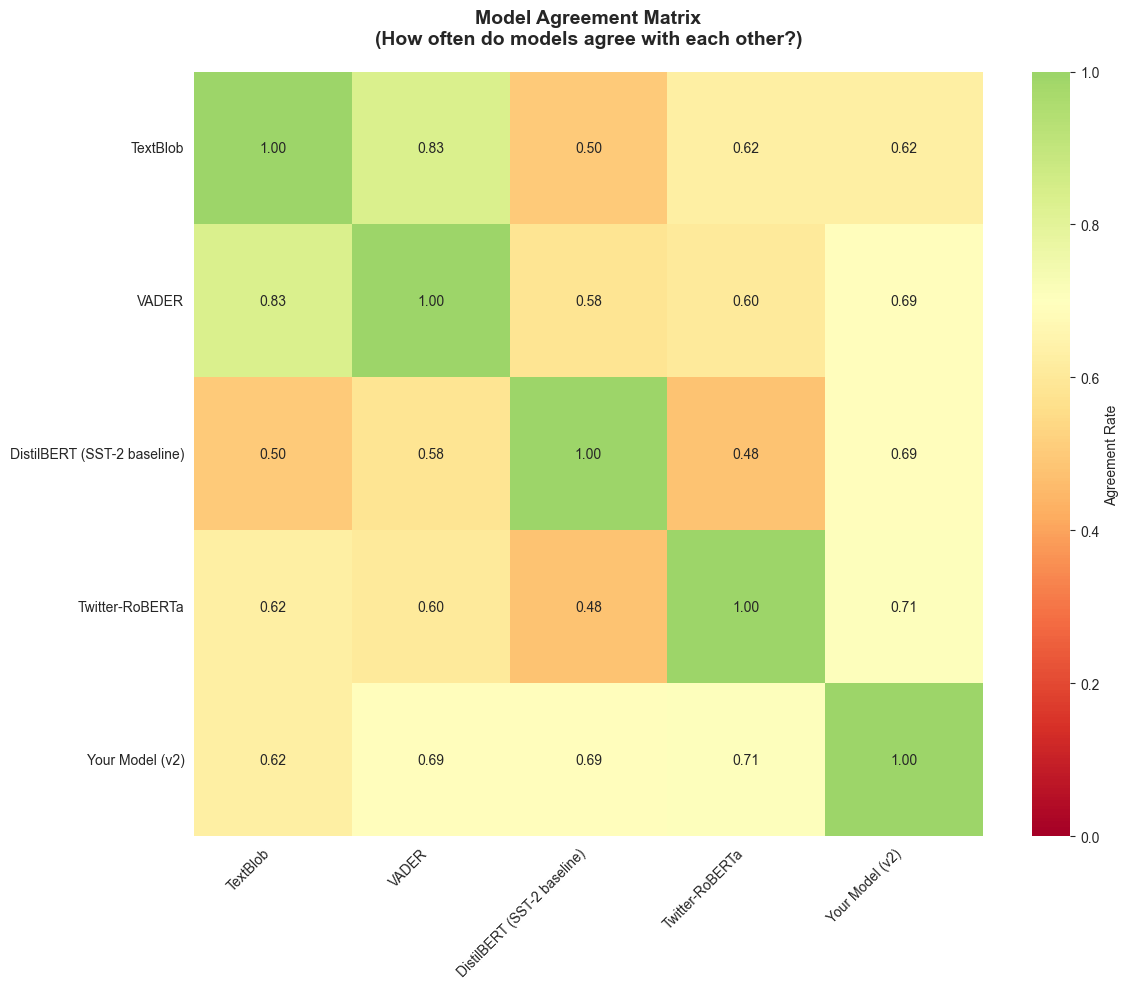

💾 Saved: sentiment_performance_by_type.html



✅ ALL VISUALIZATIONS COMPLETE!

Files saved:
  📊 sentiment_accuracy_comparison.png
  📊 sentiment_confusion_matrices.png
  📊 sentiment_score_distribution.html (interactive)
  📊 sentiment_model_agreement.png
  📊 sentiment_performance_by_type.html (interactive)
  📄 sentiment_comparison_results.csv
  📄 sentiment_metrics_summary.csv


In [7]:
# Sentiment Analysis Comparison & Visualization Script
# Run this after the setup script

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix, accuracy_score

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ============================================
# TEST DATASET
# ============================================

test_data = [
    # Simple positives
    ("I love this product!", "POSITIVE"),
    ("This is amazing and wonderful", "POSITIVE"),
    ("Best purchase ever!", "POSITIVE"),

    # Simple negatives
    ("I hate this. Terrible.", "NEGATIVE"),
    ("Worst experience ever", "NEGATIVE"),
    ("This is awful and disappointing", "NEGATIVE"),

    # Social media style
    ("THIS IS AWESOME!!! 😍🔥", "POSITIVE"),
    ("OMG this is sooo good!!!", "POSITIVE"),
    ("wtf this is trash 🗑️💩", "NEGATIVE"),
    ("worst app ever!!!!", "NEGATIVE"),

    # Slang
    ("This app is fire 🔥", "POSITIVE"),
    ("ngl this slaps fr fr", "POSITIVE"),
    ("This is mid tbh", "NEUTRAL"),
    ("big yikes, this is trash", "NEGATIVE"),

    # Sarcasm
    ("Oh great, another bug. Just what I needed.", "NEGATIVE"),
    ("Wow, amazing how it crashes every time.", "NEGATIVE"),
    ("Sure, 'working as intended' lol", "NEGATIVE"),

    # Mixed/Complex
    ("The design is beautiful but it crashes constantly", "NEGATIVE"),
    ("I wanted to love this but it's too buggy", "NEGATIVE"),
    ("It's okay, nothing special", "NEUTRAL"),

    # Neutral
    ("The product arrived on Tuesday", "NEUTRAL"),
    ("I ordered the blue one", "NEUTRAL"),
    ("It has three buttons", "NEUTRAL"),

    # Sales-domain cases (expanded, your model's actual target)
    ("Not interested at all. They are happy with their current vendor.", "NEGATIVE"),
    ("Really impressed, asked for the contract right after the call.", "POSITIVE"),
    ("Still weighing a few options, nothing decided yet.", "NEUTRAL"),
    ("Budget is approved, excited to move forward.", "POSITIVE"),
    ("Too expensive, they went with a competitor.", "NEGATIVE"),
    ("They said no thanks, sticking with what they already use.", "NEGATIVE"),
    ("Client is satisfied with their existing tool and doesn't want to switch.", "NEGATIVE"),
    ("Passed on us, going with a rival company instead.", "NEGATIVE"),
    ("Told us they're not looking to change providers this year.", "NEGATIVE"),
    ("They want to sign this week and start onboarding immediately.", "POSITIVE"),
    ("Loved the demo, ready to move to the next stage.", "POSITIVE"),
    ("Finance approved the purchase order.", "POSITIVE"),
    ("Said we're their top choice after comparing three vendors.", "POSITIVE"),
    ("Said they'd loop in their manager before responding.", "NEUTRAL"),
    ("Interested in principle, but their current contract doesn't expire for months.", "NEUTRAL"),
    ("Need to check with procurement before moving forward.", "NEUTRAL"),
    ("Asked for a follow-up call next week to discuss further.", "NEUTRAL"),
    ("Liked the product but budget got cut this quarter.", "NEGATIVE"),
    ("Complained the onboarding process was too slow and confusing.", "NEGATIVE"),
    ("Renewed with their existing provider despite our offer.", "NEGATIVE"),
    ("Very excited about the ROI numbers we presented.", "POSITIVE"),
    ("Ready to expand the pilot to their whole team.", "POSITIVE"),
    ("Still comparing pricing between us and two competitors.", "NEUTRAL"),
    ("Waiting on their legal team to review the contract terms.", "NEUTRAL"),
    ("Said the price is a dealbreaker for their budget this year.", "NEGATIVE"),
]

df_test = pd.DataFrame(test_data, columns=['text', 'true_label'])

print(f"📊 Test dataset: {len(df_test)} samples")
print(f"   - POSITIVE: {(df_test['true_label']=='POSITIVE').sum()}")
print(f"   - NEGATIVE: {(df_test['true_label']=='NEGATIVE').sum()}")
print(f"   - NEUTRAL: {(df_test['true_label']=='NEUTRAL').sum()}")

# ============================================
# RUN COMPARISON
# ============================================

model_names = ['TextBlob', 'VADER', 'DistilBERT (SST-2 baseline)', 'Twitter-RoBERTa', 'Your Model (v2)']

def run_comparison(analyzer, df):
    """Run all models on test data and collect results."""
    results = []

    print(f"\n🔄 Running comparison on {len(df)} texts...")
    print("="*60)

    for idx, row in df.iterrows():
        text = row['text']
        true_label = row['true_label']

        print(f"\n[{idx+1}/{len(df)}] {text[:50]}...")

        predictions = analyzer.analyze_all(text)

        result = {'text': text, 'true_label': true_label}

        for model_name, (pred_label, score) in predictions.items():
            result[f'{model_name}_label'] = pred_label
            result[f'{model_name}_score'] = score
            print(f"  {model_name:30s}: {pred_label:8s} ({score:+.3f})")

        results.append(result)

    print("\n✅ Comparison complete!")
    return pd.DataFrame(results)

df_results = run_comparison(analyzer, df_test)

# ============================================
# CALCULATE METRICS
# ============================================

metrics_summary = []

for model in model_names:
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        y_true = df_results['true_label']
        y_pred = df_results[label_col]

        accuracy = accuracy_score(y_true, y_pred)

        correct_pos = ((y_true == 'POSITIVE') & (y_pred == 'POSITIVE')).sum()
        correct_neg = ((y_true == 'NEGATIVE') & (y_pred == 'NEGATIVE')).sum()
        correct_neu = ((y_true == 'NEUTRAL') & (y_pred == 'NEUTRAL')).sum()

        total_pos = (y_true == 'POSITIVE').sum()
        total_neg = (y_true == 'NEGATIVE').sum()
        total_neu = (y_true == 'NEUTRAL').sum()

        metrics_summary.append({
            'Model': model,
            'Accuracy': accuracy,
            'Correct_Positive': f"{correct_pos}/{total_pos}",
            'Correct_Negative': f"{correct_neg}/{total_neg}",
            'Correct_Neutral': f"{correct_neu}/{total_neu}",
        })

df_metrics = pd.DataFrame(metrics_summary)
df_metrics = df_metrics.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📈 MODEL PERFORMANCE SUMMARY")
print("="*60)
print(df_metrics.to_string(index=False))

# ============================================
# VISUALIZATION 1: Accuracy Comparison
# ============================================

fig1, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.barh(df_metrics['Model'], df_metrics['Accuracy'], color='steelblue')
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

for bar, acc in zip(bars, df_metrics['Accuracy']):
    ax1.text(acc + 0.02, bar.get_y() + bar.get_height()/2,
             f'{acc:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sentiment_accuracy_comparison.png', dpi=300, bbox_inches='tight')
print("\n💾 Saved: sentiment_accuracy_comparison.png")
plt.show()

# ============================================
# VISUALIZATION 2: Confusion Matrices
# ============================================

fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

labels = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

for idx, model in enumerate(model_names):
    label_col = f'{model}_label'
    if label_col in df_results.columns:
        cm = confusion_matrix(df_results['true_label'],
                              df_results[label_col],
                              labels=labels)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=labels, yticklabels=labels,
                   ax=axes[idx], cbar=False)

        acc = df_metrics[df_metrics["Model"]==model]["Accuracy"].values[0]
        axes[idx].set_title(f'{model}\n(Acc: {acc:.1%})', fontweight='bold')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

for i in range(len(model_names), len(axes)):
    axes[i].axis('off')

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('sentiment_confusion_matrices.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_confusion_matrices.png")
plt.show()

# ============================================
# VISUALIZATION 3: Interactive Score Distribution
# ============================================

fig3 = make_subplots(
    rows=2, cols=3,
    subplot_titles=model_names,
    specs=[[{'type': 'box'}]*3, [{'type': 'box'}]*3]
)

colors = {'POSITIVE': 'green', 'NEGATIVE': 'red', 'NEUTRAL': 'gray'}

for idx, model in enumerate(model_names):
    row = idx // 3 + 1
    col = idx % 3 + 1
    score_col = f'{model}_score'

    if score_col in df_results.columns:
        for sentiment in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
            mask = df_results['true_label'] == sentiment
            scores = df_results[mask][score_col]

            fig3.add_trace(
                go.Box(y=scores, name=sentiment, marker_color=colors[sentiment],
                      showlegend=(idx==0)),
                row=row, col=col
            )

fig3.update_layout(
    title_text="Score Distribution by True Sentiment (All Models)",
    height=800,
    showlegend=True
)

fig3.write_html('sentiment_score_distribution.html')
print("💾 Saved: sentiment_score_distribution.html")
fig3.show()

# ============================================
# VISUALIZATION 4: Model Agreement Heatmap
# ============================================

agreement_matrix = np.zeros((len(model_names), len(model_names)))

for i, model1 in enumerate(model_names):
    for j, model2 in enumerate(model_names):
        if i == j:
            agreement_matrix[i][j] = 1.0
        else:
            col1 = f'{model1}_label'
            col2 = f'{model2}_label'
            if col1 in df_results.columns and col2 in df_results.columns:
                agreement = (df_results[col1] == df_results[col2]).mean()
                agreement_matrix[i][j] = agreement

fig4, ax4 = plt.subplots(figsize=(12, 10))
sns.heatmap(agreement_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
           xticklabels=model_names, yticklabels=model_names,
           vmin=0, vmax=1, center=0.7, ax=ax4, cbar_kws={'label': 'Agreement Rate'})
ax4.set_title('Model Agreement Matrix\n(How often do models agree with each other?)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_model_agreement.png', dpi=300, bbox_inches='tight')
print("💾 Saved: sentiment_model_agreement.png")
plt.show()

# ============================================
# VISUALIZATION 5: Performance by Text Type
# ============================================

def categorize_text(text):
    text_lower = text.lower()
    if any(x in text for x in ['!!!', '🔥', '😍', '💩', '🗑️']):
        return 'Social Media'
    elif any(x in text_lower for x in ['fire', 'slaps', 'yikes', 'mid', 'ngl', 'fr']):
        return 'Slang'
    elif any(x in text_lower for x in ['oh great', 'wow, amazing', 'sure,', 'lol']):
        return 'Sarcasm'
    elif any(x in text_lower for x in ['budget', 'vendor', 'contract', 'competitor', 'expensive']):
        return 'Sales-Domain'
    elif 'but' in text_lower or ('.' in text and len(text) > 40):
        return 'Complex'
    elif any(x in text_lower for x in ['arrived', 'ordered', 'has']):
        return 'Neutral'
    else:
        return 'Simple'

df_results['text_type'] = df_results['text'].apply(categorize_text)

type_performance = []
for text_type in df_results['text_type'].unique():
    mask = df_results['text_type'] == text_type
    for model in model_names:
        label_col = f'{model}_label'
        if label_col in df_results.columns:
            acc = accuracy_score(
                df_results[mask]['true_label'],
                df_results[mask][label_col]
            )
            type_performance.append({
                'Text Type': text_type,
                'Model': model,
                'Accuracy': acc
            })

df_type_perf = pd.DataFrame(type_performance)

fig5 = px.bar(df_type_perf, x='Text Type', y='Accuracy', color='Model',
             barmode='group', title='Model Performance by Text Type',
             height=600)
fig5.update_layout(yaxis_range=[0, 1])
fig5.write_html('sentiment_performance_by_type.html')
print("💾 Saved: sentiment_performance_by_type.html")
fig5.show()

# ============================================
# SAVE RESULTS
# ============================================

df_results.to_csv('sentiment_comparison_results.csv', index=False)
df_metrics.to_csv('sentiment_metrics_summary.csv', index=False)

print("\n" + "="*60)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("="*60)
print("\nFiles saved:")
print("  📊 sentiment_accuracy_comparison.png")
print("  📊 sentiment_confusion_matrices.png")
print("  📊 sentiment_score_distribution.html (interactive)")
print("  📊 sentiment_model_agreement.png")
print("  📊 sentiment_performance_by_type.html (interactive)")
print("  📄 sentiment_comparison_results.csv")
print("  📄 sentiment_metrics_summary.csv")

In [8]:
sales_domain_results = df_type_perf[df_type_perf['Text Type'] == 'Sales-Domain']
print(sales_domain_results.to_string(index=False))


   Text Type                       Model  Accuracy
Sales-Domain                    TextBlob       0.5
Sales-Domain                       VADER       0.5
Sales-Domain DistilBERT (SST-2 baseline)       0.5
Sales-Domain             Twitter-RoBERTa       0.7
Sales-Domain             Your Model (v2)       0.9
